In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('customer_churn.csv')
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 50.8 KB


"CustomerID","PaperlessBilling","PaymentMethod","Contract" are categorical data columns.

In [5]:
df1= df.copy(deep=True)

#### Distribution of churn vs non churn

In [6]:
# Print the raw counts (How many 0s and 1s)
print("--- Raw Counts ---")
print(df['Churn'].value_counts())

# Print percentages
print("\n--- Percentages ---")
print(df['Churn'].value_counts(normalize=True) * 100)

--- Raw Counts ---
Churn
0    447
1     53
Name: count, dtype: int64

--- Percentages ---
Churn
0    89.4
1    10.6
Name: proportion, dtype: float64


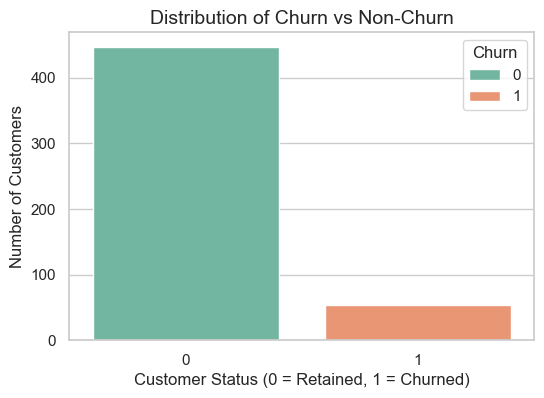

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2', hue= df['Churn'])
plt.title('Distribution of Churn vs Non-Churn', fontsize=14)
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

#### Data transformation

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['en_PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])

# verify the transformation
df[['en_PaperlessBilling', 'PaperlessBilling']].head()

,en_PaperlessBilling,PaperlessBilling
0,0,No
1,1,Yes
2,0,No
3,0,No
4,0,No


In [9]:
df['Contract'].value_counts()

Contract
One year          186
Month-to-month    170
Two year          144
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import OrdinalEncoder
contract_order = [['Month-to-month','One year','Two year']]
oe = OrdinalEncoder(categories=contract_order)
df['en_contract'] = oe.fit_transform(df[['Contract']])

#verify transform
df[['Contract','en_contract']].head()

,Contract,en_contract
0,One year,1.0
1,Month-to-month,0.0
2,Two year,2.0
3,Month-to-month,0.0
4,One year,1.0


In [11]:
df['en_contract']=df['en_contract'].astype(int)

In [12]:
df['PaymentMethod'].value_counts()

PaymentMethod
Credit Card         178
Electronic Check    163
Bank Transfer       159
Name: count, dtype: int64

In [13]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first') 
payment_encoded = ohe.fit_transform(df[['PaymentMethod']])
payment_df = pd.DataFrame(payment_encoded, columns=ohe.get_feature_names_out(['PaymentMethod']))
df = pd.concat([df, payment_df], axis=1)
print(df.columns)

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn',
       'en_PaperlessBilling', 'en_contract', 'PaymentMethod_Credit Card',
       'PaymentMethod_Electronic Check'],
      dtype='str')


#### Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
df_standardized = df.copy(deep=True)
df_standardized[num_cols] = scaler_std.fit_transform(df[num_cols])
print("--- Standard Scaled Data ---")
print(df_standardized[num_cols].describe().round(2))

--- Standard Scaled Data ---
       Tenure  MonthlyCharges  TotalCharges
count  500.00          500.00        500.00
mean     0.00            0.00          0.00
std      1.00            1.00          1.00
min     -1.72           -1.81         -1.81
25%     -0.85           -0.90         -0.89
50%      0.02            0.03         -0.02
75%      0.85            0.86          0.90
max      1.67            1.65          1.66


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
df_normalized = df.copy(deep=True)
df_normalized[num_cols] = scaler_minmax.fit_transform(df[num_cols])
print("\n--- Min-Max Scaled Data ---")
print(df_normalized[num_cols].describe().round(2))


--- Min-Max Scaled Data ---
       Tenure  MonthlyCharges  TotalCharges
count  500.00          500.00        500.00
mean     0.51            0.52          0.52
std      0.30            0.29          0.29
min      0.00            0.00          0.00
25%      0.26            0.26          0.27
50%      0.51            0.53          0.51
75%      0.76            0.77          0.78
max      1.00            1.00          1.00


In [16]:
comparison_df = pd.DataFrame({
    'Original': df['TotalCharges'],
    'Standardized (Z-score)': df_standardized['TotalCharges'],
    'Normalized (0 to 1)': df_normalized['TotalCharges']
})
print(comparison_df.head())

   Original  Standardized (Z-score)  Normalized (0 to 1)
0      1540               -1.194621             0.176305
1      1753               -1.100305             0.203498
2      1455               -1.232259             0.165454
3      7150                1.289485             0.892506
4      1023               -1.423548             0.110303


#### Outliers detection

In [17]:
# Calculate Q1, Q3, and IQR
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

# Defining boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifing outliers
iqr_outliers = df[(df['TotalCharges'] < lower_bound) | (df['TotalCharges'] > upper_bound)]

print(f"IQR Lower Bound: {lower_bound}")
print(f"IQR Upper Bound: {upper_bound}")
print(f"Number of outliers detected via IQR: {len(iqr_outliers)}")

IQR Lower Bound: -3807.0
IQR Upper Bound: 12311.0
Number of outliers detected via IQR: 0


In [18]:
import numpy as np

# Calculate mean and standard deviation
mean_val = df['TotalCharges'].mean()
std_val = df['TotalCharges'].std()

# Calculate Z-scores
df['TotalCharges_Z'] = (df['TotalCharges'] - mean_val) / std_val

# Identify outliers where absolute Z-score is greater than 3
z_outliers = df[df['TotalCharges_Z'].abs() > 3]

print(f"Number of outliers detected via Z-score: {len(z_outliers)}")

Number of outliers detected via Z-score: 0


In [19]:
import numpy as np
import pandas as pd

# Feature 1: Charges per Month of Tenure
# Tells us the actual velocity of what they pay. We add +1 to tenure to avoid division by zero errors for brand new customers.
df['Charges_Per_Month'] = df['TotalCharges'] / (df['Tenure'] + 1)

# Feature 2: Expected vs. Actual Tenure Deviation
# Mathematically, TotalCharges / MonthlyCharges should equal their tenure. If it doesn't, it indicates price hikes or mid-contract adjustments.
df['Calculated_Tenure'] = df['TotalCharges'] / (df['MonthlyCharges'] + 0.001)
df['Tenure_Mismatch'] = df['Calculated_Tenure'] - df['Tenure']

# Feature 3: High-Cost Burden Flag
# A binary flag (1 or 0) indicating if a customer's monthly charge is above the average market rate.
avg_monthly_charge = df['MonthlyCharges'].mean()
df['Is_High_Spender'] = (df['MonthlyCharges'] > avg_monthly_charge).astype(int)

# Feature 4: Tenure Cohorts (Binning)
# Categorizes loyalty into lifecycle stages. Models love categorical bins for non-linear patterns.
df['Tenure_Group'] = pd.cut(
    df['Tenure'], 
    bins=[-1, 12, 36, df['Tenure'].max()], 
    labels=['Short-Term', 'Medium-Term', 'Long-Term']
)
# Convert this new categorical feature to numbers using simple mapping so the model can read it
df['Tenure_Group_Encoded'] = df['Tenure_Group'].map({'Short-Term': 0, 'Medium-Term': 1, 'Long-Term': 2})

# Feature 5: Senior Citizen Premium Interaction
# Combines demographic data with financial data. This highlights if older citizens are on more expensive plans.
df['Senior_Financial_Weight'] = df['SeniorCitizen'] * df['MonthlyCharges']

# Verify that your dataframe now has these new columns
print("New columns successfully added:")
print(df[['Charges_Per_Month', 'Tenure_Mismatch', 'Is_High_Spender', 'Tenure_Group_Encoded', 'Senior_Financial_Weight']].head())

New columns successfully added:


   Charges_Per_Month  Tenure_Mismatch  Is_High_Spender Tenure_Group_Encoded  \
0         220.000000        18.062124                0                    0   
1          79.681818        -5.486863                0                    1   
2          51.964286        19.933970                0                    1   
3         132.407407       193.543223                0                    2   
4          60.176471       -10.470300                1                    1   

   Senior_Financial_Weight  
0                       64  
1                      113  
2                       31  
3                       29  
4                      185  


In [20]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Define columns to drop from the training features
columns_to_drop = ['CustomerID', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'Tenure_Group', 'Churn']

# Isolate features (X) and target (y)
# errors='ignore' ensures it won't crash if a column was already dropped
X = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')
y = df['Churn']

print(f"Features ready for analysis ({X.shape[1]} columns):")
print(list(X.columns))

Features ready for analysis (15 columns):
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'en_PaperlessBilling', 'en_contract', 'PaymentMethod_Credit Card', 'PaymentMethod_Electronic Check', 'TotalCharges_Z', 'Charges_Per_Month', 'Calculated_Tenure', 'Tenure_Mismatch', 'Is_High_Spender', 'Tenure_Group_Encoded', 'Senior_Financial_Weight']


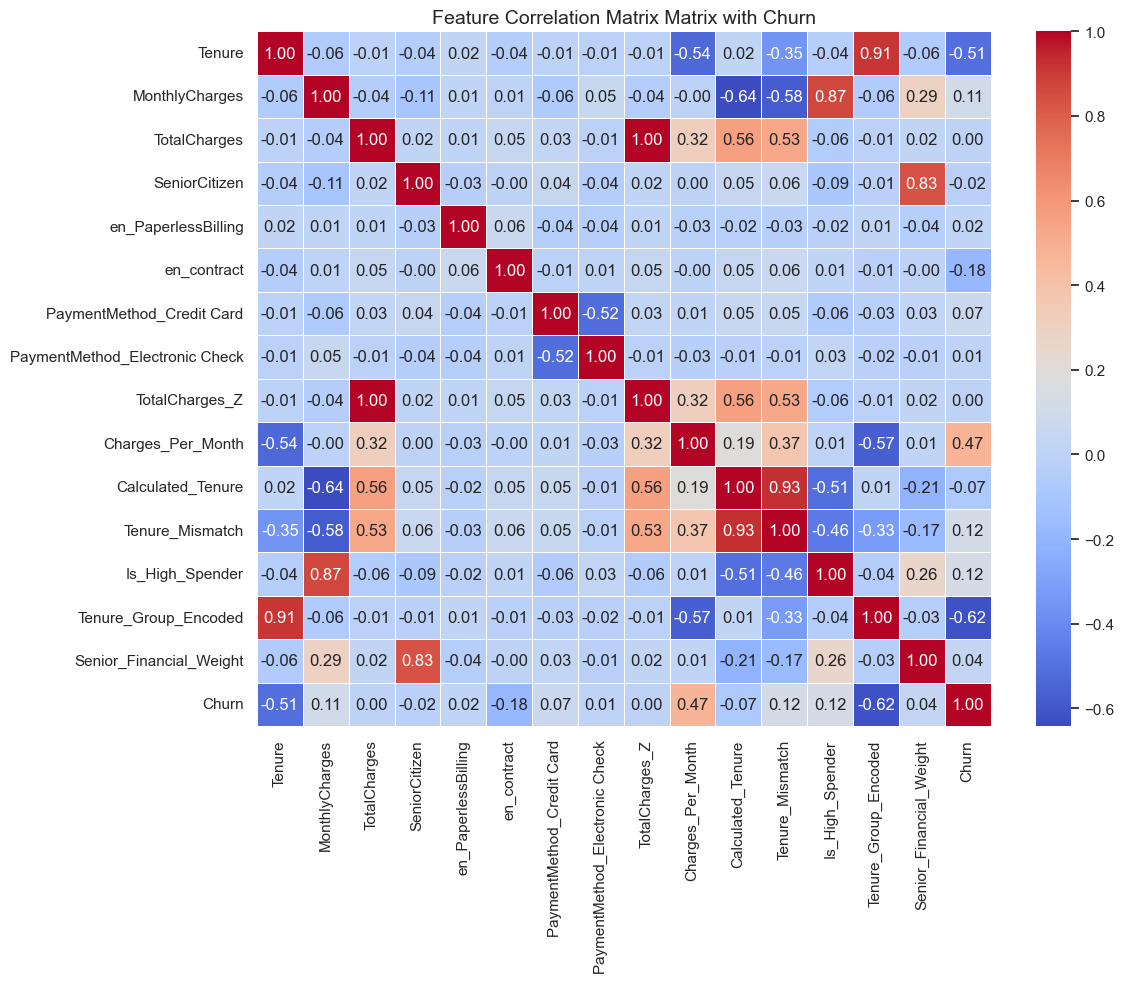

--- Linear Correlation with Churn Target ---
Churn                             1.000000
Charges_Per_Month                 0.471932
Is_High_Spender                   0.124120
Tenure_Mismatch                   0.120181
MonthlyCharges                    0.107381
PaymentMethod_Credit Card         0.069635
Senior_Financial_Weight           0.037652
en_PaperlessBilling               0.016145
PaymentMethod_Electronic Check    0.010007
TotalCharges_Z                    0.004250
TotalCharges                      0.004250
SeniorCitizen                    -0.018114
Calculated_Tenure                -0.073066
en_contract                      -0.182759
Tenure                           -0.509208
Tenure_Group_Encoded             -0.616368
Name: Churn, dtype: float64


In [21]:
# Create a temporary dataframe including Churn for correlation plotting
corr_df = X.copy()
corr_df['Churn'] = y

# Calculate correlation matrix
corr_matrix = corr_df.corr()

# Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix Matrix with Churn', fontsize=14)
plt.tight_layout()
plt.show()

# Print sorted correlation specifically with the Churn target
print("--- Linear Correlation with Churn Target ---")
print(corr_matrix['Churn'].sort_values(ascending=False))

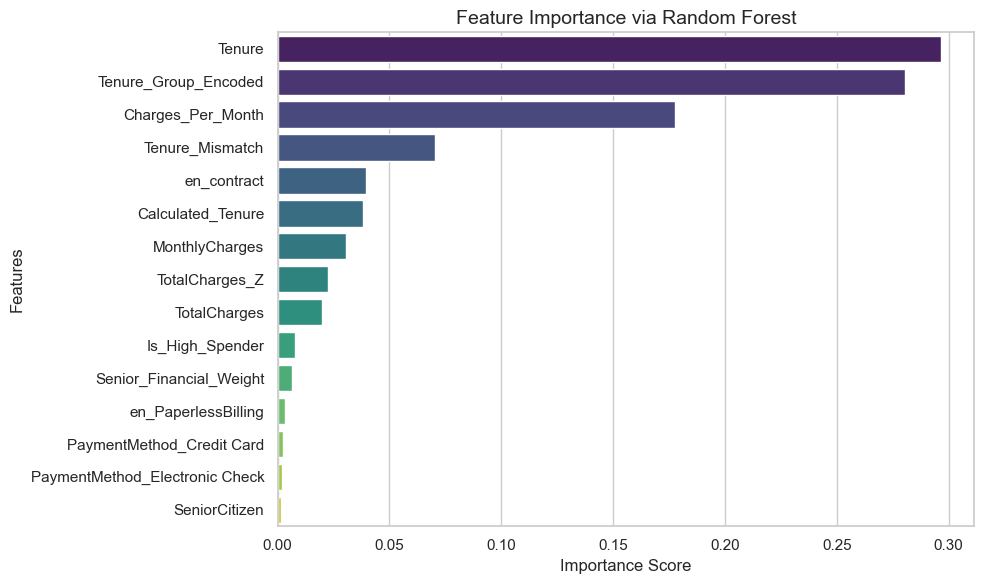

--- Feature Importance Ranking ---
                       Feature  Importance
                        Tenure    0.296499
          Tenure_Group_Encoded    0.280534
             Charges_Per_Month    0.177599
               Tenure_Mismatch    0.070428
                   en_contract    0.039500
             Calculated_Tenure    0.038365
                MonthlyCharges    0.030742
                TotalCharges_Z    0.022723
                  TotalCharges    0.019834
               Is_High_Spender    0.007937
       Senior_Financial_Weight    0.006437
           en_PaperlessBilling    0.003388
     PaymentMethod_Credit Card    0.002507
PaymentMethod_Electronic Check    0.002115
                 SeniorCitizen    0.001392


In [25]:
# Initialize Random Forest (stratified class_weight handles your 89/11 class imbalance)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Fit the model to find patterns
rf.fit(X, y)

# Extract importances into a clean DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance via Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Display the ranked list
print("--- Feature Importance Ranking ---")
print(feature_importance_df.to_string(index=False))

In [26]:
# Example: Select features that have an importance score greater than 0.02
threshold = 0.02
selected_features = feature_importance_df[feature_importance_df['Importance'] >= threshold]['Feature'].tolist()

print(f"\nFeatures selected for the Day 7 Pipeline (Importance >= {threshold}):")
print(selected_features)

# Filter your training matrix to keep only these columns
X_selected = X[selected_features]


Features selected for the Day 7 Pipeline (Importance >= 0.02):
['Tenure', 'Tenure_Group_Encoded', 'Charges_Per_Month', 'Tenure_Mismatch', 'en_contract', 'Calculated_Tenure', 'MonthlyCharges', 'TotalCharges_Z']


In [29]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

class CustomerChurnPipeline(BaseEstimator, TransformerMixin):
    def __init__(self):
        # We define the 8 exact features selected on Day 6
        self.selected_features = [
            'Tenure', 'Tenure_Group_Encoded', 'Charges_Per_Month', 
            'Tenure_Mismatch', 'en_contract', 'Calculated_Tenure', 
            'MonthlyCharges', 'TotalCharges_Z'
        ]
        self.scaler = StandardScaler()
        
    def fit(self, X, y=None):
        # We need to fit our scaler on the numerical features during training
        # To avoid data leakage, fitting happens only on training data
        X_engineered = self._engineer_features(X)
        
        # Identify columns that need scaling (everything except encoded columns)
        self.cols_to_scale = [col for col in self.selected_features if col != 'Tenure_Group_Encoded' and col != 'en_contract']
        
        self.scaler.fit(X_engineered[self.cols_to_scale])
        return self
        
    def transform(self, X):
        # 1. Apply all Day 2 and Day 5 transformations
        X_engineered = self._engineer_features(X)
        
        # 2. Filter down to only the 8 selected features
        X_filtered = X_engineered[self.selected_features].copy()
        
        # 3. Apply the fitted scaling from Day 3
        X_filtered[self.cols_to_scale] = self.scaler.transform(X_filtered[self.cols_to_scale])
        
        return X_filtered

    def _engineer_features(self, df_raw):
        # Creating a safe working copy to prevent SettingWithCopyWarnings
        df_out = df_raw.copy()
        
        # --- Day 2: Encoding ---
        # Map contract types to ordered numbers (Ordinal Encoding)
        contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
        df_out['en_contract'] = df_out['Contract'].map(contract_mapping).fillna(0).astype(int)
        
        # --- Day 4 & Day 5: Feature Engineering & Processing ---
        # Calculate Z-score element for TotalCharges as requested by Day 6 output
        mean_tc = df_out['TotalCharges'].mean()
        std_tc = df_out['TotalCharges'].std() if df_out['TotalCharges'].std() != 0 else 1
        df_out['TotalCharges_Z'] = (df_out['TotalCharges'] - mean_tc) / std_tc
        
        # Calculations
        df_out['Charges_Per_Month'] = df_out['TotalCharges'] / (df_out['Tenure'] + 1)
        df_out['Calculated_Tenure'] = df_out['TotalCharges'] / (df_out['MonthlyCharges'] + 0.001)
        df_out['Tenure_Mismatch'] = df_out['Calculated_Tenure'] - df_out['Tenure']
        
        # Tenure Grouping
        df_out['Tenure_Group'] = pd.cut(
            df_out['Tenure'], 
            bins=[-1, 12, 36, float('inf')], 
            labels=['Short-Term', 'Medium-Term', 'Long-Term']
        )
        df_out['Tenure_Group_Encoded'] = df_out['Tenure_Group'].map({'Short-Term': 0, 'Medium-Term': 1, 'Long-Term': 2}).fillna(0).astype(int)
        
        return df_out

# ==========================================================
# TEST THE PIPELINE END-TO-END
# ==========================================================

# 1. Load your original clean raw data (assuming df contains original 9 columns)
# Ensure you are passing the raw un-preprocessed columns to test authenticity
raw_data_sample = df[['Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen']]

# 2. Instantiate and run the pipeline
churn_pipeline = CustomerChurnPipeline()
X_processed = churn_pipeline.fit_transform(raw_data_sample)

# 3. Check performance output
print("Pipeline Successfully Executed!")
print(f"Processed Shape: {X_processed.shape} (Rows, Features)")
print("\nFirst 5 Processed Rows ready for Machine Learning Model:")
X_processed.head().round(4)

Pipeline Successfully Executed!
Processed Shape: (500, 8) (Rows, Features)

First 5 Processed Rows ready for Machine Learning Model:


,Tenure,Tenure_Group_Encoded,Charges_Per_Month,Tenure_Mismatch,en_contract,Calculated_Tenure,MonthlyCharges,TotalCharges_Z
0,-1.4788,0,-0.0399,0.0369,1,-0.5459,-0.9592,-1.1946
1,-0.7523,1,-0.3733,-0.3854,0,-0.7098,-0.0123,-1.1003
2,-0.4617,1,-0.4392,0.0705,2,-0.1074,-1.5969,-1.2323
3,0.7976,2,-0.2480,3.1837,0,3.7192,-1.6355,1.2895
4,-0.9945,1,-0.4197,-0.4748,1,-0.9012,1.3791,-1.4235
